In [142]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmocean as cmo
import matplotlib.dates as mdates
from scipy.integrate import cumulative_trapezoid #, trapz

# start= pd.to_datetime(ds['time'].values[0], unit='D', origin='julian')


############################## OPEN MODEL DATA ##############################
ds = xr.open_dataset("FlocMod_ADV_G_21.nc", decode_times=False)
volume = 4/3 * np.pi * (ds.Ds/2)**3 
date = pd.to_datetime("2020-07-16 20:10:01")
ds = ds.dropna(dim="N", how="any")
mtime = [date + pd.Timedelta(t, unit='s') for t in ds.time.values]
nt = len(ds.time) 
Nens = len(ds.N)
Ns = len(ds.Ds)

print(ds)

############################## OPEN ADCP DATA ##############################
adcp = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/data/usgs/resampled_adcp_usgs.nc") #, decode_times=False)
rtime = adcp.time.values #[low:high]
offset= 3.537306921274909
levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]
adcp_u = np.squeeze(adcp.u_1205)
adcp_z = adcp.depth.values
print(adcp.lon.values, adcp.lat.values)



############################## DEFINE SUPPORTING FUNCTIONS ##############################

def julian_to_datetime(julian_days, seconds_, base_julian=2440000, base_date_str="1968-05-23 00:00:00"):
    # 1. Establish your datum anchor point

    julian_days = np.asarray(julian_days)
    seconds_ = np.asarray(seconds_)
    base_date = np.datetime64(base_date_str)
    days_diff = (julian_days - base_julian) * np.timedelta64(1, 'D')
    seconds = seconds_ * np.timedelta64(1, 'ms')
    dates = base_date + days_diff + seconds
    return dates

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

############################## OPEN LISST DATA ##############################
fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/CSF20SC104ls-b.nc"
lds = xr.open_dataset(fn, decode_times=False)
ldates = julian_to_datetime(lds['time'].values, lds['time2'].values)
lds = lds.assign_coords(time=ldates)

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 300, Ds: 40, N: 50)
Coordinates:
  * time     (time) float32 1kB 0.0 1.5e+03 3e+03 ... 4.47e+05 4.485e+05
  * Ds       (Ds) float32 160B 1e-06 1.206e-06 1.455e-06 ... 0.001244 0.0015
  * N        (N) float32 200B 1.0 2.0 3.0 4.0 5.0 ... 46.0 47.0 48.0 49.0 50.0
Data variables:
    ssc      (time, Ds, N) float64 5MB 5.67e+03 32.9 2.423e+03 ... 9.335e-13 0.0
    G        (time, N) float64 120kB 16.43 16.43 16.43 ... 14.24 14.24 14.24
    nf       (time, N) float64 120kB 1.554 1.586 1.709 ... 2.746 2.447 1.64
    alpha    (time, N) float64 120kB 0.7522 0.49 0.03991 ... 0.4774 0.0507
    beta     (time, N) float64 120kB 0.04212 0.08722 0.02306 ... 0.02302 0.01536
    beta2    (time, N) float64 120kB 0.9334 1.473 0.6922 ... 2.316 1.181 2.04
Attributes:
    title:    floc mod test
[-122.16842] [37.54722]


<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1838229/2157808090.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[j].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))


Text(0.5, 0, 'Time [hr]')

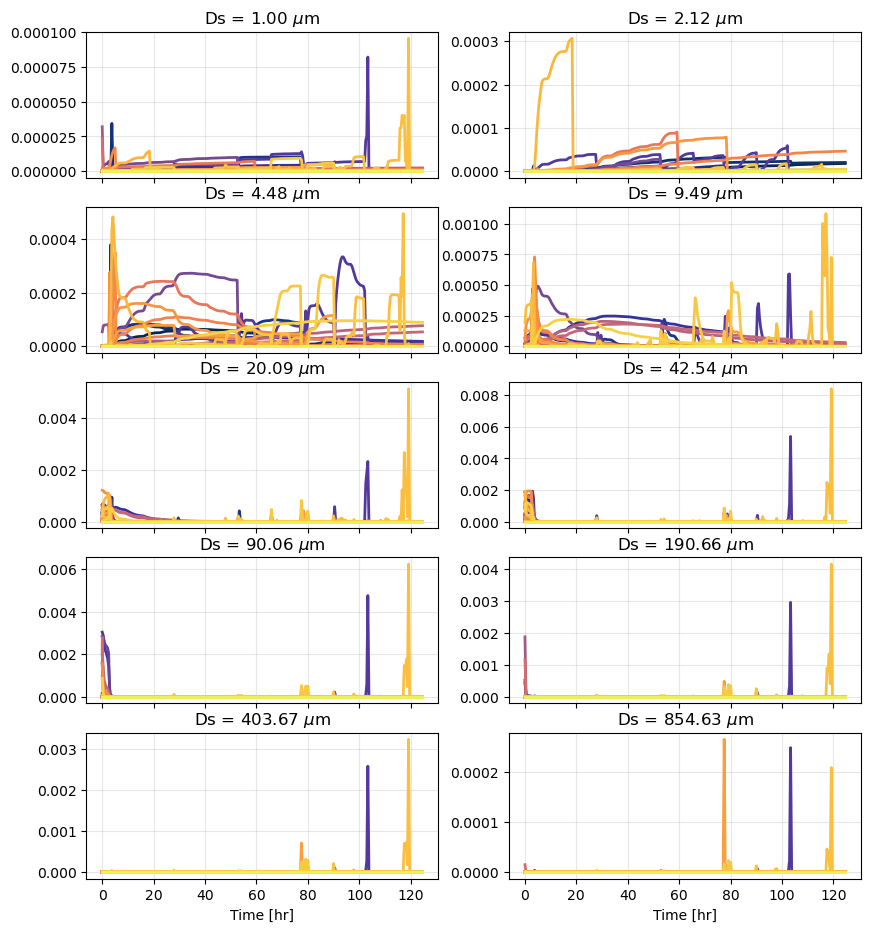

In [132]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 11), sharex=True, sharey=False)
axs = axs.flatten()


for j, Ds in enumerate(range(0, Ns, 4)):
    if j > 9:
        continue
    axs[j].grid(alpha=0.3)
    axs[j].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))
    time = ds.time.values / 3600
    for i in range(0, Nens):
        G = ds.G.isel(time=1, N=i)
        s0 = ds.ssc.isel(N=i).isel(Ds=Ds) * volume[Ds] * 1e6
        axs[j].plot(time, s0, color=cmo.cm.thermal(i/Nens), linewidth=2) #, label="Nens=%d" % i)

# axs[-5].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
axs[-1].set_xlabel("Time [hr]")
axs[-2].set_xlabel("Time [hr]")

# fig.savefig("time_evolution_G=%d.png" % (G), dpi=300, bbox_inches='tight')

<xarray.DataArray (time: 300, Ds: 10)> Size: 24kB
array([[2.96858449e-09, 1.83054660e-09, 3.21951578e-09, ...,
        5.80168530e-08, 1.13084189e-07, 3.08170062e-07],
       [3.64922774e-09, 1.83274930e-09, 3.22741853e-09, ...,
        6.63755163e-08, 1.71638509e-07, 8.98370022e-07],
       [3.89287251e-09, 1.83375122e-09, 3.23102269e-09, ...,
        7.44717117e-08, 2.27351234e-07, 1.40641923e-06],
       ...,
       [6.90885208e-09, 3.99392149e-15, 2.44627808e-17, ...,
        4.64840611e-07, 5.17889206e-10, 1.60069584e-05],
       [7.61426349e-09, 1.44425404e-14, 9.66086250e-17, ...,
        1.01094798e-06, 1.08004073e-09, 2.73446974e-05],
       [8.19159364e-09, 4.09031888e-14, 2.84721932e-16, ...,
        1.79764807e-06, 1.80527617e-09, 3.94193798e-05]], shape=(300, 10))
Coordinates:
  * time     (time) float32 1kB 0.0 1.5e+03 3e+03 ... 4.47e+05 4.485e+05
  * Ds       (Ds) float32 40B 1e-06 1.206e-06 1.455e-06 ... 4.482e-06 5.407e-06
    N        float32 4B 1.0
Attributes:
    un

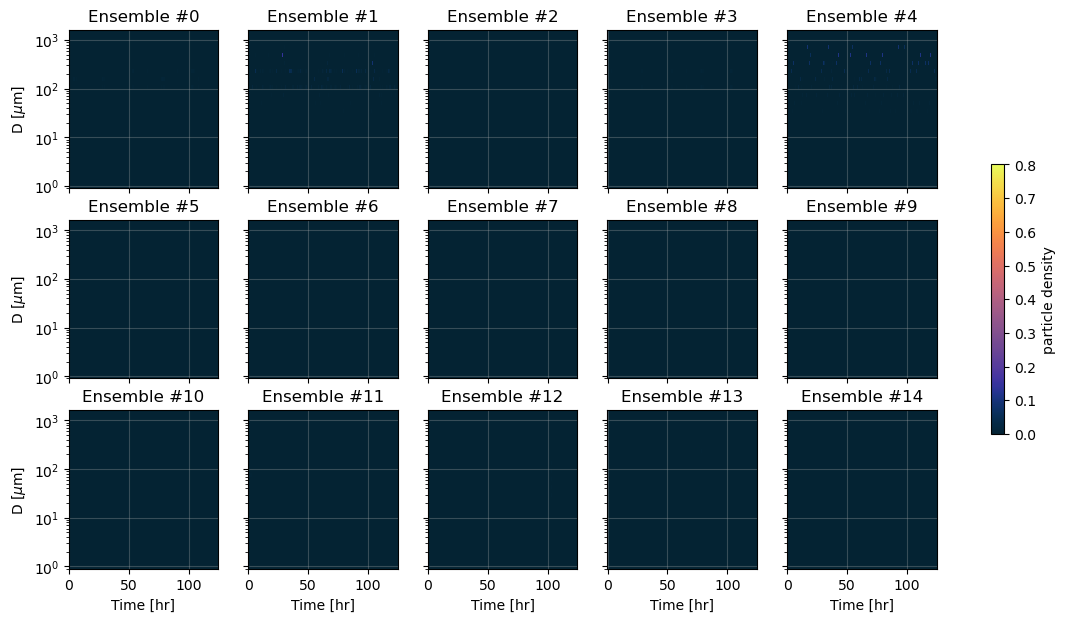

In [133]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(14, 7), sharex=True, sharey=True)
axs[0,0].set_ylabel(r"D [$\mu$m]")
axs[1,0].set_ylabel(r"D [$\mu$m]")
axs[2,0].set_ylabel(r"D [$\mu$m]")

for j in range(5):
    axs[2,j].set_xlabel("Time [hr]")
axs = axs.flatten()


for i in range(0, 15):
    G = ds.G.isel(time=1, N=i)
    axs[i].grid(alpha=0.3)
    axs[i].set_title("Ensemble #%d" % i)
    time = ds.time.values / 3600
    ssc = ds.ssc.isel(N=i) * volume * 1e6
    print(ssc[0:, 0:10])
    h = axs[i].pcolormesh(time, ds.Ds.values*1e6, ssc.T, cmap=cmo.cm.thermal, shading='auto', vmin=0, vmax=0.8)
    axs[i].set_yscale("log")
    

plt.colorbar(h, ax=axs, orientation='vertical', label="particle density", shrink=0.5)

# fig.savefig("time-space_G=%d.png" % (G), dpi=300, bbox_inches='tight')

<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1838229/2516153260.py:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[it].set_ylabel("$\mu$L/L") #  10$^6$ particles/m$^3$


300


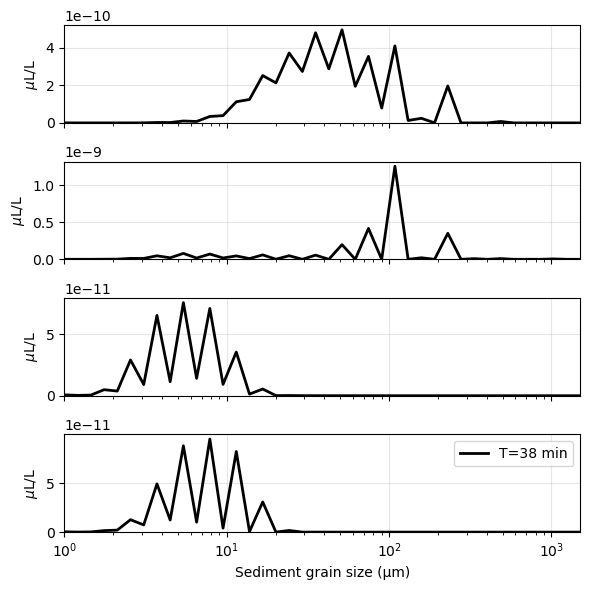

In [134]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(6, 6), sharex=True, sharey=False)


t = 50 
print(nt)

for it, t in enumerate(range(6, nt, nt//4)):
    Ds = ds.Ds.values*1e6
    label="T=%d min" % (t*10/60)
    # for i in range(0, Nens):
    #     var = ds.ssc.isel(time=t, N=i) * volume.isel(N=i)
    #     axs[it].plot(Ds, var, '-', color=cmo.cm.haline(i/Nens), linewidth=2, alpha=0.1) #,color=cmo.cm.thermal(t/nt))

    mean = ds.ssc.isel(time=t).mean(dim="N")* volume
    axs[it].plot(Ds, mean, '-', color='k', linewidth=2, label=label)

    axs[it].set_xscale('log')
    axs[it].grid(alpha=0.3)
    axs[it].set_ylabel("$\mu$L/L") #  10$^6$ particles/m$^3$
    axs[it].set_ylim(0,)
    axs[it].set_xlim(Ds[0], Ds[-1])

axs[-1].set_xlabel("Sediment grain size (µm)")
axs[-1].legend()

plt.tight_layout()

# fig.savefig("pdf_G=%d.png" % (G), dpi=300, bbox_inches='tight')

Text(0.5, 0.98, '0-D Flocculation Model vs LISST D$_{50}$')

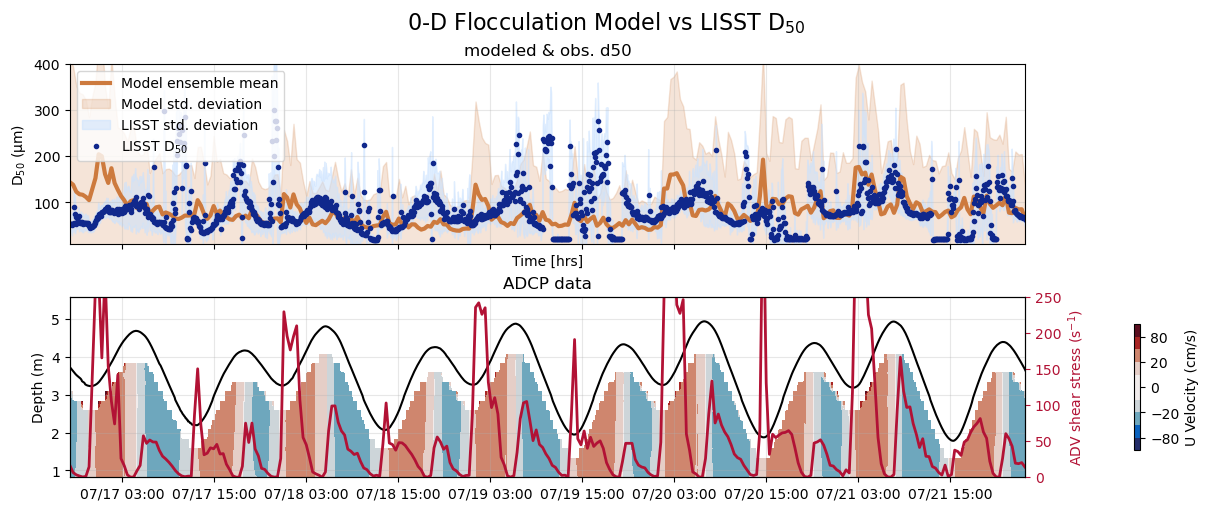

In [135]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 5), sharex=True, sharey=False, constrained_layout=True)

var = ds.ssc.mean(dim='N')
weights = var.values + 1e-9
Ds = np.broadcast_to(ds.Ds.values, var.values.shape)
mean_d = np.average(Ds, axis=1, weights=weights)

################## SHEAR STRESS FROM THE ADV  ##################
shear = ds.G.isel(N=0) 
ax = axs[0]
ax2 = axs[1].twinx()
ax2.plot(mtime, shear, '-', color='#B21235', linewidth=2, label="Shear stress")
ax2.set_ylim(0,250)
ax2.tick_params(axis='y', colors='#B21235')
ax2.set_ylabel("ADV shear stress (s$^{-1}$)", color='#B21235')

# Number of particles 
var = ds.ssc # shape = (1380, 10, 250)
Ds_aligned = ds.Ds.values[None, :, None]
weights = var  *  volume #[None, :, :] 
mean_d = np.sum(Ds_aligned * weights, axis=1) / np.sum(weights, axis=1) 
std_ = mean_d.std(axis=1)

################## MODELLED D50 ##################
mean_d = np.mean(mean_d, axis=1)
ax.plot(mtime, mean_d*1e6, color='#CD7A3E', linewidth=3, label="Model ensemble mean") 
ax.fill_between(mtime, np.squeeze(mean_d-std_)*1e6, np.squeeze(mean_d+std_)*1e6, color="#CD7A3E", alpha=0.2, label="Model std. deviation")


################## FORMAT AXES ##################
ax.grid(alpha=0.3)
ax.set_xlabel("Time [hrs]")
ax.set_ylabel("D$_{50}$ (µm)")
ax.set_ylim(10, 400) 


################## LISST DATA ##################
d50 = lds['D50'].isel(depth=0)
stds = lds['D50'].std(axis=1) 
d50 = lds['D50'].mean(axis=1)

ax.fill_between(ldates, np.squeeze(d50-stds), np.squeeze(d50+stds), color='#CBE2FE', alpha=0.55, label="LISST std. deviation")
ax.plot(ldates, d50, 'o', color='#10288C', label="LISST D$_{50}$", markersize=3)
format_date_ax(ax, 12)

# Add ADCP 
h = axs[1].contourf(rtime, -adcp_z + offset, adcp_u.T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[1].grid(alpha=0.3)
depths =  np.squeeze(adcp.P_1.values) #+ 0.41
axs[1].plot(rtime, depths, color='k', label='Depth')
axs[1].set_ylabel("Depth (m)")
axs[0].legend()


axs[0].set_title("modeled & obs. d50")

axs[1].set_title("ADCP data")

ax.set_xlim(mtime[0], mtime[-1])
plt.suptitle("0-D Flocculation Model vs LISST D$_{50}$", fontsize=16)
# ax.set_yscale('log')
# ax.set_title("Shear = %d s$^{-1}$" % G)

# fig.savefig("d50_G=%d.png" % (G), dpi=300, bbox_inches='tight')

<>:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1838229/2661308087.py:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')


1.0176306286996475
1.0176332618532982
1.0176331189188246
1.017641187034905
1.017632916317475
1.0176332661188416
1.017657015325277
1.0176331992045204
1.017633409016036
1.0176333874516739
1.0176331364001154
1.0176327434801824
1.0176331056606351
1.0176329065398966
1.017633191652269


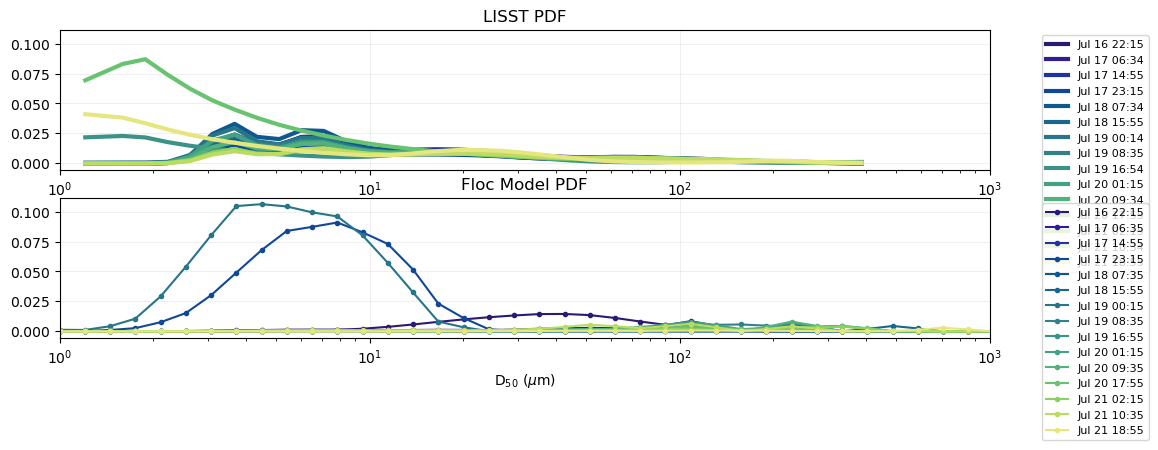

In [136]:
# LISST size classes // append last element
x = lds.size_class.values 
x = np.append(x, x[-1])

fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=True)

def date2color(date, cmap=cmo.cm.haline):
    d0 = pd.to_datetime(ldates[i])
    d1 = (d0 - mtime[-1]).total_seconds() 
    normalize = (d0 - date).total_seconds() / d1
    return cmo.cm.haline(normalize)

Ds_ = ds.Ds.values*1e6        
with np.errstate(divide='ignore', invalid='ignore'):
    for i in range(5, 300, 20):
        conc = ds.ssc.isel(time=i)
        conc = conc*volume
        conc = conc.mean(dim='N').values

        cdf_integrated = cumulative_trapezoid(conc, Ds_, initial=0)
        cdf = cdf_integrated / cdf_integrated[-1]   

        pdf = np.gradient(cdf, Ds_)
        print(np.trapezoid(pdf, Ds_))

        # 4. Plot the CDF against your x-axis (Ds)
        color = date2color(mtime[i]) 
        axs[1].plot(Ds_, pdf, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

        ### Plot equivalent LISST data
        cdf = lds.CDF.sel(time=mtime[i], method='nearest').isel(depth=0)
        cdf = cdf.mean(dim='sample')
        pdf = np.gradient(cdf, x)
        d0 = pd.to_datetime(cdf.time.values)
        color = date2color(d0) 
        axs[0].plot(x, pdf, '-', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

axs[1].set_title("Floc Model PDF")
axs[0].set_title("LISST PDF")
# axs[0].set_ylim(0, 0.05)   

for ax in axs:
    ax.set_xlim(1, 1000)
    
    ax.set_xlabel('D$_{50}$ ($\mu$m)')
    ax.grid(alpha=0.2)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xscale('log')

<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1838229/2841205931.py:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')


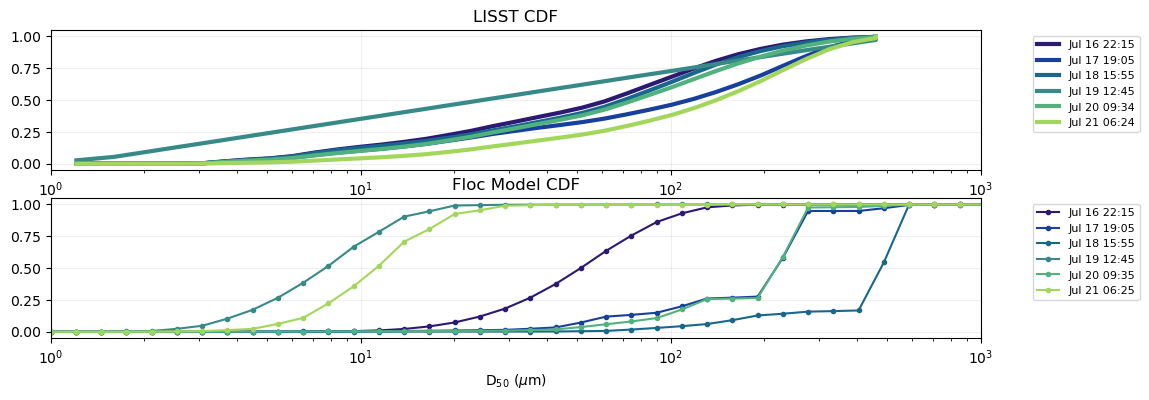

In [137]:
# CDF 

fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=False)
     
for i in range(5, 300, 50):

    conc = ds.ssc.isel(time=i)

    conc = conc*volume/np.sum(volume*conc)
    conc = conc.mean(dim='N').values


    cdf_integrated = cumulative_trapezoid(conc, Ds_, initial=0)
    cdf = cdf_integrated / cdf_integrated[-1]   

    # 4. Plot the CDF against your x-axis (Ds)
    color = date2color(mtime[i]) 
    axs[1].plot(Ds_, cdf, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    ### Plot equivalent LISST data

    cdf = lds.CDF.sel(time=mtime[i], method='nearest').isel(depth=0)
    cdf = cdf.mean(dim='sample')

    d0 = pd.to_datetime(cdf.time.values)
    color = date2color(d0) 
    axs[0].plot(x, cdf, '-', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

axs[1].set_title("Floc Model CDF")
axs[0].set_title("LISST CDF")

for ax in axs:
    ax.set_xlim(1, 1000)
    
    ax.set_xlabel('D$_{50}$ ($\mu$m)')
    # ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.2)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ax.set_xscale('log')

<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1838229/2154786451.py:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')
/tmp/ipykernel_1838229/2154786451.py:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A r

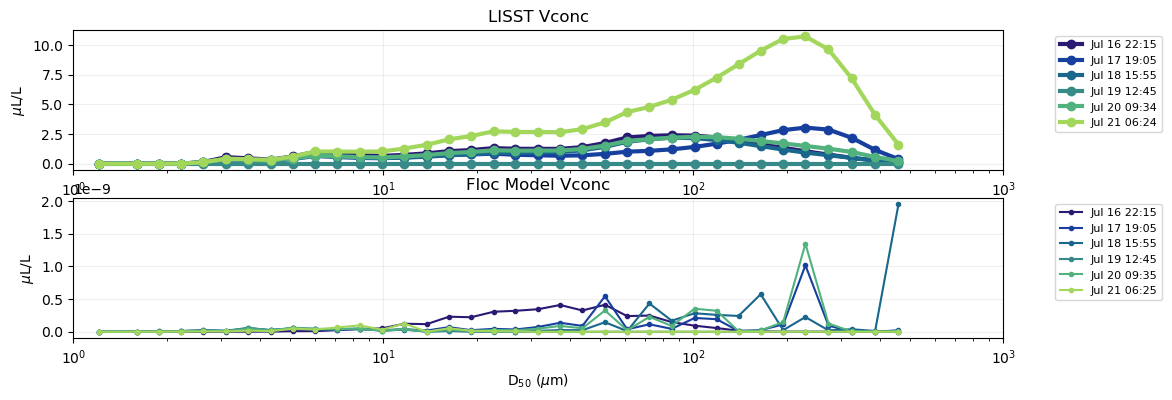

In [138]:
# volume concentration

fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=False)
     
for i in range(5, 300, 50):
    conc = ds.ssc.isel(time=i)
    conc = conc*volume 
    conc = conc.mean(dim='N').values 

    # 4. Plot the CDF against your x-axis (Ds)
    color = date2color(mtime[i]) 
    interpolated = np.interp(x[0:-1], Ds_, conc) 
    # axs[1].plot(Ds_, conc, '--', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))
    axs[1].plot(x[0:-1], interpolated, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    # axs[1].plot(Ds_, conc, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    ### Plot equivalent LISST data
    cdf = lds.vconc.sel(time=mtime[i], method='nearest').isel(depth=0)
    cdf = cdf.mean(dim='sample')

    d0 = pd.to_datetime(cdf.time.values)
    color = date2color(d0) 
    axs[0].plot(x[0:-1], cdf, '-o', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

axs[1].set_title("Floc Model Vconc")
axs[0].set_title("LISST Vconc")

for ax in axs:
    ax.set_xlim(1, 1000)
    
    ax.set_xlabel('D$_{50}$ ($\mu$m)')
    # ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.2)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ax.set_xscale('log')
    ax.set_ylabel("$\mu$L/L")
    # print(lds.vconc)

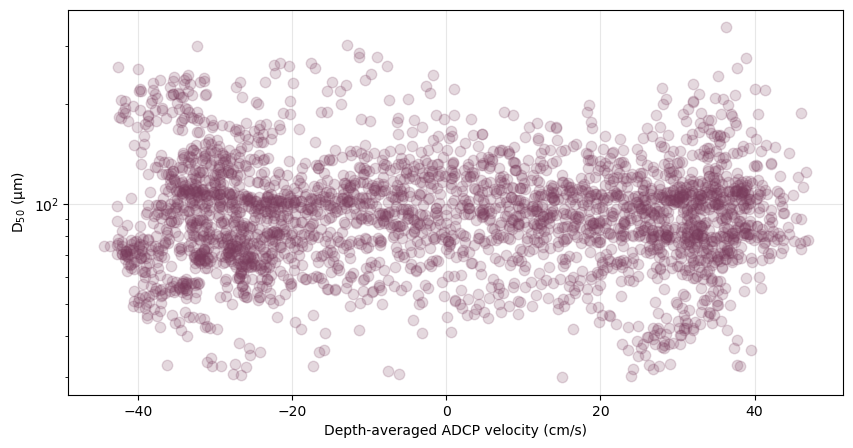

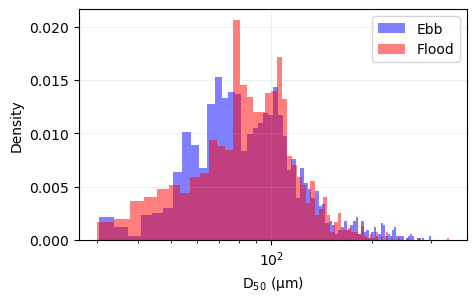

In [139]:

# interpolate LISST data and ACDP data
df_l = pd.Series(np.squeeze(d50), index=ldates)
df_v = pd.DataFrame(index=rtime) 
df_v['velocity'] = adcp_u.mean(dim='depth')

# Interpolate df_l on df_v index
df_l_interp = df_l.reindex(df_v.index.union(df_l.index)).interpolate('time').reindex(df_v.index)


df_v['d50'] = df_l_interp
df_v.dropna(inplace=True)
df_v = df_v[df_v['d50'] > 30] # remove negative values

fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

ax.plot(df_v.velocity, df_v.d50, '.', color='#7A3D5D', label="LISST D$_{50}$", alpha=0.2, markersize=15)
ax.set_yscale('log')
ax.set_xlabel("Depth-averaged ADCP velocity (cm/s)")
ax.set_ylabel("D$_{50}$ (µm)")
ax.grid(alpha=0.3)

# Histogram for flood and ebb 
ebb = df_v[df_v.velocity < 0]
flood = df_v[df_v.velocity > 0]
fig = plt.figure(figsize=(5, 3))
ax = plt.gca()
ax.hist(ebb.d50, bins=80, alpha=0.5, label="Ebb", color='b', density=True)
ax.hist(flood.d50, bins=80, alpha=0.5, label="Flood", color='r', density=True)
ax.set_xscale('log')
ax.set_xlabel("D$_{50}$ (µm)")
ax.grid(alpha=0.2)
ax.set_ylabel("Density")
ax.legend()

alpha: 0.33758157281260276 0.23655353640485793
0.03893952951039984 0.23655353640485793
1.9524070110101177 0.3328578283216439
alpha: 0.33758157281260287 0.23655353640485788
0.038939529510399855 0.23655353640485788
1.9524070110101177 0.3328578283216437
alpha: 0.33758157281260287 0.23655353640485788
0.038939529510399876 0.23655353640485788
1.9524070110101177 0.3328578283216437
alpha: 0.33758157281260287 0.23655353640485788
0.03893952951039988 0.23655353640485788
1.9524070110101177 0.3328578283216437


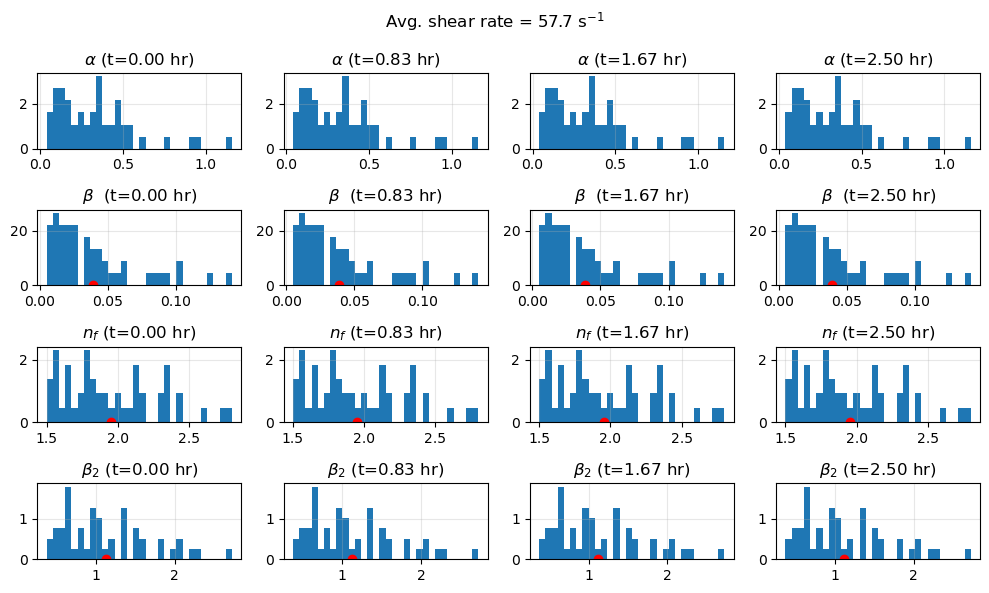

In [140]:
import numpy as np 

fig, axs = plt.subplots(figsize=(10, 6), nrows=4, ncols=4, sharex=False)
shears = ds.G.values.flatten()
shear = np.mean(shears)
plt.suptitle(r"Avg. shear rate = %2.1f s$^{-1}$" % shear) #%.2f hr" % (ds.time.isel(time=i).values/3600))

total = 11
for i, t in enumerate(range(0, total, total//4)):

    if i>3:
        continue
    alphas = ds.alpha.isel(time=t).values
    betas = ds.beta.isel(time=t).values
    nfs = ds.nf.isel(time=t).values
    beta2s = ds.beta2.isel(time=t).values
    axs[0, i].hist(alphas, density=True, bins=30) 
    print("alpha:" ,np.mean(alphas), np.std(alphas))
    print(np.mean(betas), np.std(alphas))
    print(np.mean(nfs), np.std(nfs))


    axs[0, i].set_title(r"$\alpha$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[1, i].hist(betas, density=True, bins=30) 
    axs[1, i].plot(np.mean(betas), 0, 'ro', label="mean")
    axs[1, i].set_title(r"$\beta$  (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))

    axs[2, i].hist(nfs, density=True, bins=30) 
    axs[2, i].set_title("$n_f$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[2, i].plot(np.mean(nfs), 0, 'ro', label="mean")


    axs[3, i].hist(beta2s, density=True, bins=30)
    axs[3, i].set_title(r"$\beta_2$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[3, i].plot(np.mean(beta2s), 0, 'ro', label="mean")

for ax in axs.flatten():
    ax.grid(alpha=0.3)
plt.tight_layout()
    # axs[0].set_yscale('log')
    # axs[1].set_yscale('log')
    # axs[2].set_y

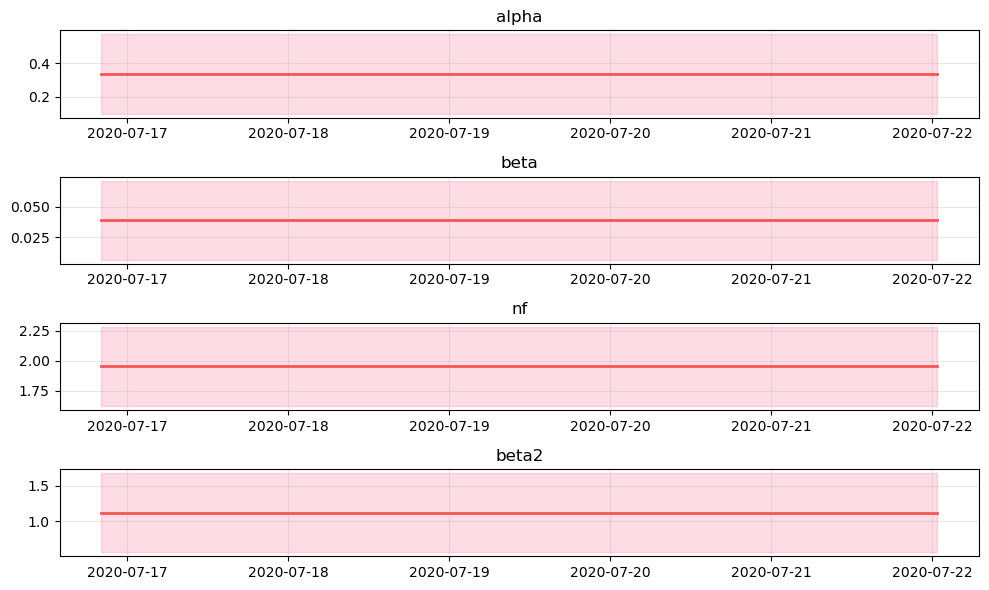

In [141]:
fig, axs = plt.subplots(figsize=(10, 6), nrows=4, ncols=1, sharex=False)

for iv, variable in enumerate(['alpha', 'beta', 'nf', 'beta2']):
    var = ds[variable]
    mean_var = var.mean(dim='N').values
    std_var = var.std(dim='N').values
    axs[iv].plot(mtime, mean_var, color="#F95454", linewidth=2, label="Mean %s" % variable)
    axs[iv].fill_between(mtime, np.squeeze(mean_var-std_var), np.squeeze(mean_var+std_var), color="#F9547F", alpha=0.2, label="Std. deviation")
    axs[iv].set_title(variable)
    axs[iv].grid(alpha=0.3)

plt.tight_layout()